In [18]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.ticker as ticker
import math
from sklearn import decomposition
import random 

## Project Overview

Data from Moritz as part of the VICTORIA cohort (?). 

**Research Question**: Does vitamin D3 supplementation impact the plasma proteome of patients with colorectal cancer (CRC)? 

To test this, patients were given a very high baseline does of vit. d3 for 11 days follows by a daily maintence dose *for X days*. Plasma samples are collected from patientsd at baseline (t0); week 2 to 3 of the trial after initial high dose (t1?); and at the end of the intervention at week 12-16 (t2).

Moritz conducted a preliminary analysis comparing timepoints  & treatment group (vit d vs placebo). There are other relevant clinical groups that should be further analyzed, for example, CRC-stage at time of diagnosis, initial vit-D level, age, sex, smoking, alcohol consuption, chemo/radiotherapy, etc. 

#### Technical Details for Data processing

Each plate containes 8 QC samples in position 12. These are plasma samples that were digested seperately for each injection . . . so a type of technical replicate. 



In [ ]:
meta_dat = pd.read_excel("PEVIDS/PEVIDS_plasma/dat/meta-data/vic_data_for_moritz_final.xlsx") ## defaults first sheet
meta_dat.head()

In [ ]:
data_dic = pd.read_excel("PEVIDS/PEVIDS_plasma/dat/meta-data/dataset_moritz_variables_Tomislav(1).xlsx", header = 3)
data_dic ## data dictionary is fine to download locally bc it is not data

#data_dic[data_dic['Variable name'] == "sex"]

In [ ]:
## how do we describe the meta data? (also clinical data, etc)

meta_dat.describe() ## obviously need to pick specific variabkles and not everything. Plus some - like sex, this is categorical not numerical
## so you need to look at the data dictionary to see how the information is encoded and what it means

## some info we might be interested in 
# distribution of weight, age, sex, vit_d . . . etc

# Read in & Format Data

In [23]:
## read in data
pg = pd.read_csv("PEVIDS/PEVIDS_plasma/dat/report.pg_matrix.tsv", sep = "\t")
print(pg.shape)
pg.head()
len(pg['Protein.Group'].unique())


(485, 1217)


485

In [ ]:
pg.set_index('Protein.Group', inplace=True)
        ## fix column names to fit pnumber names
samp_list = pg.columns.to_list() # drop(['Protein.Ids', 'Genes', 'First.Protein.Description'],
samplist = [x.replace(' ', '').split("\\")[-1].rstrip(".d") for x in samp_list ] ## may want to further refine if the key sampID is in between underscores
pg.columns = samplist
## fix some possible column name problems
extra_cols = ['Protein.Ids' , 'Genes' , 'First.Protein.Description'] ## will this work if these cols not there?
all_samps = [x.replace('__', '_').replace(' ', '').split('_') for x in set(samplist ) - set(extra_cols)] #if x.startswith(r'[0-9]')] ## remove spaces
samp_map = pd.DataFrame(all_samps)
samp_map.columns = ["plate_num", 'position', 'pnum', 'personal_plate_num', 'replicate', 'consec_num', "x", "consec_num_2"]
samp_map['ms_consec_num'] = samp_map['consec_num_2'].fillna(samp_map['consec_num'])         ## due to formatting issues
## correct og_name (original name) with ms consec number thing
samp_map['og_name'] = samp_map["plate_num"].astype(str) + "_" + samp_map['position'].astype(str) + "_" + samp_map['pnum'] + "_" + samp_map['personal_plate_num'] +"_" + samp_map['replicate'] + "_"+ samp_map['x'].astype(str) + "_" + samp_map['ms_consec_num'].astype(str) 
samp_map['og_name'] = samp_map['og_name'].replace(to_replace = "_None", value = "", regex = True)
samp_map.drop(columns = ['consec_num', 'x', 'consec_num_2'], axis = 1, inplace = True)

samp_map.head()

# Remove Contaminants

In [25]:
## remove contaminants 
## this source from the hao group seems quite reliable with diff sample type contaminants
# https://github.com/HaoGroup-ProtContLib/Protein-Contaminant-Libraries-for-DDA-and-DIA-Proteomics 
## be sure to cite 
contam_dat = pd.read_csv("PEVIDS/PEVIDS_plasma/dat/HaoGroup_ContaminantUniversalProteins.csv", skiprows = 1) ## in the same utils/ folder 
contam_dat.drop(['Status'], axis = 1, inplace = True) 
contam_ids = list(contam_dat['Uniprot ID'])

## apply to our data
measured_contaminants = pg.loc[pg['Protein.Ids'].isin(contam_ids)]
## remove columns (samples) with no measured NA
measured_contaminants.dropna(axis = 1, how = 'all', inplace = True)
measured_contaminants =  contam_dat.merge(measured_contaminants, how = 'right', right_on = 'Protein.Ids', left_on = 'Uniprot ID')
## write this to a seperate file in the results so ppl can ID on their own if they want to. 
contam_file_name = os.path.join(f"results/contaminants_ided_with_intensities_source.csv") ## no outdir for nextflow file handling
measured_contaminants.to_csv(contam_file_name)
## give some info to log file
count_of_contams = len(measured_contaminants['Uniprot ID'].unique())
print(f"Identified {count_of_contams} contaminants in the data;\nWriting IDed contaminants and intensities to files . . . ")

## now remove these contaminants from our data
pg_filt = pg[~pg['Protein.Ids'].isin(contam_ids)]
og_rows = pg.shape[0]
new_rows = pg_filt.shape[0]
ids_removed = og_rows - new_rows
print(f"Applying contaminant filtering . . . ")#\n\tactual number of rows (IDs) removed is {ids_removed} (compared to the number of contaminants we IDs, {count_of_contams}; these numbers should be equal)")
if ids_removed == count_of_contams:
    print("\tExpected number of contaminants removed!")
else:
    print(f"\tSomething weird happened; we identified {count_of_contams} contaminants, but removed {ids_removed} rows. Please manually inspect.")
pg_filt.drop(['Genes', 'First.Protein.Description','Protein.Ids','Protein.Names' ], axis = 1, inplace=True)  # for pr: 'Proteotypic', 'Stripped.Sequence', 'Modified.Sequence','Precursor.Charge',  'Precursor.I'

pg_filt.head()

Identified 28 contaminants in the data;
Writing IDed contaminants and intensities to files . . . 
Applying contaminant filtering . . . 
	Expected number of contaminants removed!


/tmp/ipykernel_19406/4234486340.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  measured_contaminants.dropna(axis = 1, how = 'all', inplace = True)
/tmp/ipykernel_19406/4234486340.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pg_filt.drop(['Genes', 'First.Protein.Description','Protein.Ids','Protein.Names' ], axis = 1, inplace=True)  # for pr: 'Proteotypic', 'Stripped.Sequence', 'Modified.Sequence','Precursor.Charge',  'Precursor.I'


,6545_C10_P091772_P04_R1_4905,6551_A08_P092288_P10_R1_4476,6546_E01_P091883_P05_R1_5133,6954__C04_P100040_P12_R1_1_1_18779,6545_D11_P091785_P04_R1_4918,6955__A07_P100115_P13_R1_1_1_18858,6551_A07_P092287_P10_R1_4475,6551_D11_P092327_P10_R1_4515,6953__C06_P099946_P11_R1_1_1_18680,6953__A04_P099920_P11_R1_1_1_18654,...,6547_G12_P091990_P06_R1_5245,6543_H12_P091642_P02_R1_4361,6543_F04_P091610_P02_R1_4329,6543_F08_P091614_P02_R1_4333,6549_F12_P092162_P08_R1_4741,6543_E08_P091602_P02_R1_4321,6543_E12_P091606_P02_R1_4325,6543_H11_P091641_P02_R1_4360,6953__D12_P099964_P11_R1_1_1_18698,6955__A09_P100117_P13_R1_1_1_18860
Protein.Group,,,,,,,,,,,,,,,,,,,,,
A0A075B6H7,215142.00,317549.00,271076.00,299595.000,204211.00,179683.0,218420.00,179620.00,160279.00,198519.0,...,251031.00,240172.000,161237.000,207969.00,226460.000,250999.000,199343.00,118385.00,316662.00,284983.0
A0A075B6H9,1832.21,2456.20,3310.38,928.078,2496.12,NaN,1096.84,1548.18,1055.92,NaN,...,1898.23,2725.370,2172.270,1615.29,1669.850,924.662,1808.15,2121.49,2675.91,NaN
A0A075B6I0,19140.20,21784.80,11779.10,15222.300,44179.70,17558.1,10837.40,14133.10,42145.60,27564.0,...,9120.54,11878.900,64229.000,30241.10,10820.900,27954.000,10244.90,10133.40,12510.30,17669.1
A0A075B6I1,12029.70,13511.50,NaN,NaN,13995.70,17685.4,11415.20,10275.60,18931.70,17247.8,...,17834.30,18911.200,12170.000,12356.90,15640.200,12248.200,17592.60,15635.50,22255.50,NaN
A0A075B6I4,NaN,1380.08,1285.61,NaN,4413.32,NaN,NaN,NaN,NaN,NaN,...,NaN,769.674,891.483,1197.05,968.558,2221.500,NaN,1056.51,NaN,NaN


# Checking Missingness and Apply Filters

In [26]:
## quantify missingness
missingness_threshold = 0.70
## do we want to replace zero with the lowest value observed in the df near zero? (to prevent issues at next step)
pg_filt.columns = pg_filt.columns.str.replace("__", "_")
intensity_cols = pg.filter(regex="[0-9]", axis = 1).dropna(how = "all")  ## axis - 1 for cols ; drop to remove peptides IDed but not quantified
## also, zeroes are valid values here too
min_intensity = min(i for i in intensity_cols.stack().sort_values().head(n=5) if i > 0)     ## needs for whole DF!! 
print("Minimum detected intensity greater than zero: ", min_intensity)
# remove rows in which the PEPTIDE is observwed in fewer than 70% of samples 
pg_filled = pg_filt.dropna(thresh=(float(missingness_threshold)*(pg.filter(regex="[0-9]", axis = 1).shape[-1]))) # thresh = 70% of samples if sampler cols start with  number, ie plate numbers
filler = str(missingness_threshold*100)
new_name_pg_filled = os.path.join(f"report.pg_missingness_filled_at_{filler}.csv") ## no outdir for netflow file handl    pg_filled.to_csv(new_name_pg_filled)

print(pg_filt.shape) ## 457
count_b4_na_filt = pg_filt.shape[0]
count_after_na_filt = pg_filled.shape[0]  ## 334 
print(f"Before applying any NA filter, there were {count_b4_na_filt} protein groups IDed in all samples. After applying a 70% abundance threshold, this changed to {count_after_na_filt} protein groups.")

Minimum detected intensity greater than zero:  45.6234
(457, 1212)
Before applying any NA filter, there were 457 protein groups IDed in all samples. After applying a 70% abundance threshold, this changed to 327 protein groups.


In [27]:
457-327

130

# Apply Normalization

Check MS drift, log transform, and within and across plate normalization. 

In [28]:
def apply_ms_drift_plot(dat, samp_map, file_str = ""):
    """ Plot MS Drift - mean intensity across plate(s)"""
    print("there are a total of ", len(samp_map['plate_num'].unique()), " unique plates.")
    palette_len = len(samp_map['plate_num'].unique())
    custom_palette = sns.color_palette("tab20b", palette_len)

    # visualize log2 trans. on batches 
    qc_check = dat.select_dtypes(include=['number']).describe()[:3]
    qc_check = qc_check.select_dtypes(include=['number']).transpose()
    qc_check['name_from_intensity'] = qc_check.index
    qc_check['pnum'] = qc_check.apply(lambda x:  x['name_from_intensity'].split("_")[2], axis = 1)
    qc_check = pd.merge(qc_check, samp_map, on = "pnum", how = "outer")

    ## now plot QC check to examine if we see mean log2 transf. MS Drift by ms consec num
    some_name = str(file_str)
    ## plot
    fig, ax = plt.subplots(figsize=(8, 5))  
    ms_drift_plot = sns.scatterplot(ax=ax,data = qc_check, x = "ms_consec_num", y = "mean", hue = "plate_num", palette = custom_palette)
    #specfiy axis labels
    ms_drift_plot.set(xlabel='MS Consec. Number',
        ylabel='Mean Intensity',
        title=f'MS Drift: {some_name}')
    ## make legend pretty
    ms_drift_plot.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
    ms_drift_plot.set(xticklabels=[])  # remove the tick labels
    ms_drift_plot.tick_params(bottom=False)  # remove the ticks

    ms_drift_plot.figure.savefig(f"results/qc_ms_drift_{some_name}.png") 

there are a total of  14  unique plates.


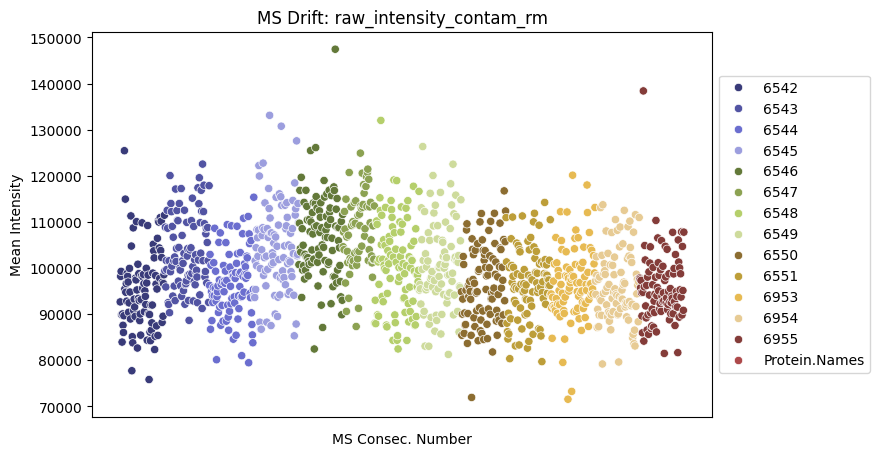

In [29]:
## before NAs removed
apply_ms_drift_plot(pg_filt, samp_map, file_str = "raw_intensity_contam_rm")

there are a total of  14  unique plates.


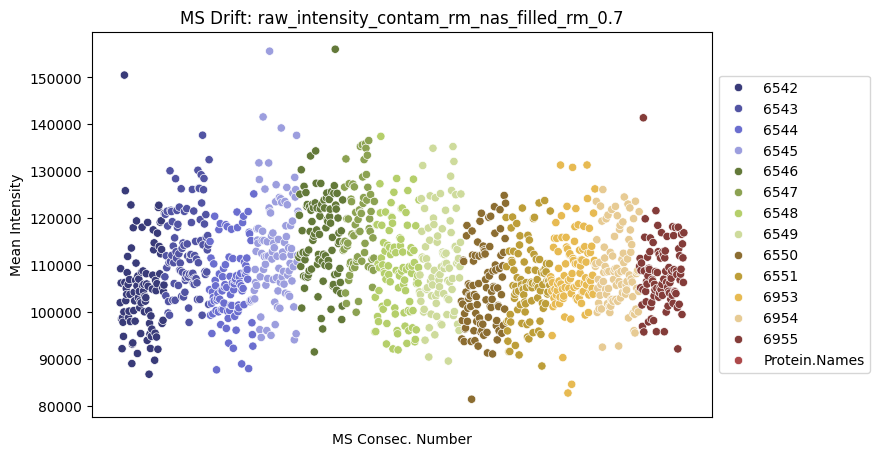

In [30]:
## after NAs removed
apply_ms_drift_plot(pg_filled, samp_map, file_str = f"raw_intensity_contam_rm_nas_filled_rm_{missingness_threshold}")

In [31]:
pg_filt.shape ## 457, 1212
pg_filled.shape ## 327 
457 - 327 # 130 proteins removes

130

In [32]:
def apply_log2(df, samp_map): ## samp_map is second output from get_datamatrix
    """ Applying log2 transformation and initial correction """
    ## corrected median intensity
    # corrected intensity is (original intensity / sample median) * mean of protein in batch (plate)
    df_t = df.transpose()#.drop(['plate_num','name_from_intensity']) ## want samples as rows, pg groups as columns
    #df_t = df_t.rename(columns=df_t.iloc[0])
    df_t['name_from_intensity'] = df_t.index
    
    df_t['name_from_intensity'] = df_t.apply(lambda x: re.sub(r'[\W_]+','_', str(x['name_from_intensity'])), axis = 1)
    df_t['pnum'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[2], axis = 1)
    ## add the plate info!
    df_t = pd.merge(df_t, samp_map, on = "pnum", how = "left") ## this adds plate num
    df_t_int = df_t.filter(regex="[0-9]", axis = 1)
    df_t_int.rename(columns=lambda s: s.replace(";", "_or_"), inplace=True)
    pg_names = df_t_int.columns.to_list()
    df_t_int.index = df_t['plate_num']

    ## for batcvh below
    df_t['plate_num'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[0], axis = 1)
    batch_sub = df_t.loc[:,['plate_num','name_from_intensity']]
    plates = df_t_int.groupby(['plate_num'])
    ## now calculate one median value per plate
    plate_medians = pd.DataFrame(plates.median()).apply(lambda x: x.median(),axis = 1) ## already groupbydf
    plates_mean = round(plate_medians.mean(),6)
    plate_medians = pd.DataFrame(plate_medians)
    plate_medians.columns = ['plate_median']

    ## cout no plate num . . . .
    df_t_int.loc[df_t_int.index.isna() =="True"]
    ## first, get the median of each sample within a batch, and ID the mean of medians
    ## mean of medians, but spread to two lines
    df_t_int['row_median'] = df_t_int.apply(lambda x: x.median(), axis=1) ## sample median, calc without low values
    df_t_int['group_mean'] = df_t_int.groupby('plate_num')['row_median'].transform('mean') ## batch mean of medians
    df_t_int.index = df_t['name_from_intensity'] ## to ensure downstream merging is to specific samples
    #df_t_int.head() ## samples as rows

    ### implementing a check: check out samples that aren't catched by the plate number coding
    werid_samples = df_t.loc[df_t.plate_num.isna()]
    count_in_both, count_not_in_exp = 0,0
    in_meta_dat_pnum = []
    for pnum in samp_map['pnum']:
        if pnum in werid_samples['pnum']:
            count_in_both += 1
        elif pnum not in werid_samples['pnum']:
            count_not_in_exp += 1
            in_meta_dat_pnum.append(pnum)

    ## note: some samples weird weird bc they were missing the QC label
    ## i'm keeping this check because it is a good sanity check, but there should be no more weird values
    print("The following number are in both meta data and our weird samples list: ", count_in_both)
    print("The following number are pnumbers in metadata but not in our weird samples list (aka normal behavior): ", count_not_in_exp) 
    print("The following number are the pnumbers that are flagged by our weird sample list and not in the meta-data file: ", len(werid_samples['pnum'].unique()))
    print("This could be due to QC samples not being properly labelled, or something else with how you named your samples. The QC process will continue, but you may be missing samples . . . \n It is your responsibility to check.")

    #######################################################
    ## apply log2 transf; WITHIN-PLATE INTENSITY CORRECTION
    medians = df_t_int['row_median'] ## samples as rows, aka sample medians
    group_means = df_t_int['group_mean'] ## mean of plate medians
    
    # drop the last two columns for the intensity calculations
    df_t_int2 = df_t_int[pg_names]
    corrected_intensities = (df_t_int2.div(medians, axis=0)).mul(group_means, axis=0)
    ## make columns numeric not objectdataset_2
    cols = corrected_intensities.columns
    corrected_intensities[cols] = corrected_intensities[cols].apply(pd.to_numeric, errors='coerce')

    ## drop na coolumns (unlikely but possible)
    corrected_intensities = corrected_intensities.dropna(axis = 1, how = "all")

    ###### batch corr
    ## probs faster way to make list as long as the OG df before the groupby>>median but here is whats in my brain rn
    plate_intermediate = pd.merge(batch_sub, plate_medians, on = "plate_num", how= "outer")
    plate_intermediate.index = plate_intermediate['name_from_intensity']
    plate_intermediate.sort_index(inplace = True)
    ## now divide samples by plate median multuple by exp mean
    pg_batch_corr = corrected_intensities.div(plate_intermediate['plate_median'], axis = 0).mul(plates_mean, axis = 0) 
    print(f"The mean intensity value from the input data for all plates is {plates_mean}.")


    ##log2
    log2_pg = np.log2(pg_batch_corr)
    log2_pg = log2_pg.round(6) ## samples as rows
   
    return(log2_pg,  pg_batch_corr)

In [33]:
pg_log2, intermediate_batch_pg = apply_log2(pg_filled, samp_map)
pg_log2.head()

The following number are in both meta data and our weird samples list:  0
The following number are pnumbers in metadata but not in our weird samples list (aka normal behavior):  1213
The following number are the pnumbers that are flagged by our weird sample list and not in the meta-data file:  0
This could be due to QC samples not being properly labelled, or something else with how you named your samples. The QC process will continue, but you may be missing samples . . . 
 It is your responsibility to check.
The mean intensity value from the input data for all plates is 13944.561538.


/tmp/ipykernel_19406/500665863.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_t_int.rename(columns=lambda s: s.replace(";", "_or_"), inplace=True)
/tmp/ipykernel_19406/500665863.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_t_int['row_median'] = df_t_int.apply(lambda x: x.median(), axis=1) ## sample median, calc without low values
/tmp/ipykernel_19406/500665863.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,A0A075B6Q5,...,Q9BXR6,Q9HDC9,Q9NPH3,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7
name_from_intensity,,,,,,,,,,,,,,,,,,,,,
6542_A01_P091451_P01_R1_4367,17.377064,11.034874,13.744287,13.543155,12.069009,14.206264,13.710306,10.811458,12.155813,14.947821,...,13.508918,10.810146,10.706128,11.708572,12.245433,13.520347,10.641486,12.591081,11.909247,12.251743
6542_A02_P091452_P01_R1_4368,17.683407,NaN,12.016330,13.266071,13.185082,12.159351,11.244994,11.076237,11.254026,15.481328,...,13.754102,10.734670,NaN,11.358023,12.074195,12.726299,11.301946,12.529067,10.272403,12.338958
6542_A03_P091453_P01_R1_4369,17.954887,NaN,8.691386,13.269757,12.989126,12.625586,13.467352,10.290713,11.571977,15.591494,...,13.863781,NaN,10.785657,11.181161,12.265424,12.471371,10.446624,12.520042,11.302571,11.919721
6542_A04_P091454_P01_R1_4370,17.223355,11.830096,13.034660,13.692706,12.797327,14.192889,13.216896,10.568687,11.307443,14.786380,...,13.678588,11.327447,11.678979,12.175162,12.404416,12.992443,10.105808,12.610372,10.902450,11.541519
6542_A05_P091455_P01_R1_4371,17.121517,10.011064,13.435364,12.927644,11.694579,14.098731,13.074893,10.287475,11.452554,14.899842,...,13.341431,NaN,10.653836,11.264047,11.484061,13.743413,10.889301,12.524856,12.190419,12.779340


there are a total of  14  unique plates.


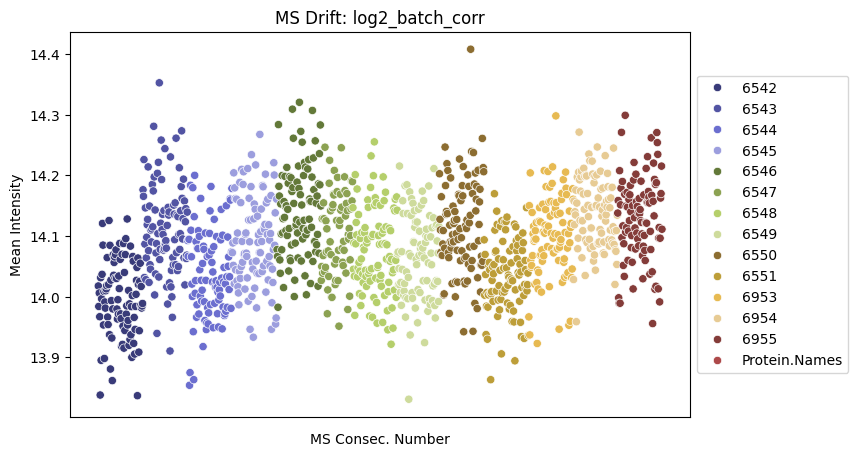

In [34]:
## after NAs removed
apply_ms_drift_plot(pg_log2.T, samp_map, file_str = "log2_batch_corr")

there are a total of  14  unique plates.


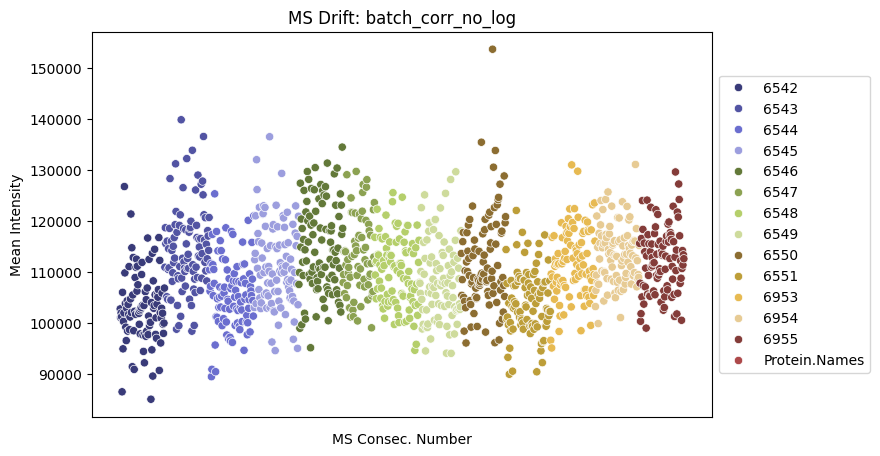

In [35]:
## after batch correction / median normalization 
apply_ms_drift_plot(intermediate_batch_pg.T, samp_map, file_str = "batch_corr_no_log")

## PyCombat

The missing value imputation method has a huge impact on downstream results, so I'm going to apply pycombat and confirm that we can get the same results weith more realistic data with that. 


**edit: turns out pyCombat requires no NAs so this is not a good method, ignoring**


In [ ]:
pg_log2['name_from_intensity'] = pg_log2.index
pg_log2['plate_num'] = pg_log2.apply(lambda x:  x['name_from_intensity'].split("_")[0], axis = 1)
pg_log2.head()

In [40]:
batch_info = np.where(
    pg_log2['plate_num'].astype(str).str.startswith('65'),
    'before_cleaning',
    np.where(
        pg_log2['plate_num'].astype(str).str.startswith('69'),
        'after_cleaning',
        None
    )
)

print(len(batch_info))


1212


In [ ]:
## remove extra cols from pg 
plot_dat = pg_log2.copy()
plot_dat.index = batch_info
plot_dat = plot_dat.drop(['plate_num','name_from_intensity'], axis = 1)
pg_log2_int = pg_log2.drop(['plate_num','name_from_intensity'], axis = 1).T ## samples as cols 
pg_log2_int.head()


#plot_dat.index = plot_dat.index.str.cat(map(str, range(1, plot_dat.shape[0]+1)), sep='_')


In [42]:
# https://matplotlib.org/stable/gallery/color/named_colors.html 

In [43]:
before = plot_dat.loc['before_cleaning']
after = plot_dat.loc['after_cleaning']

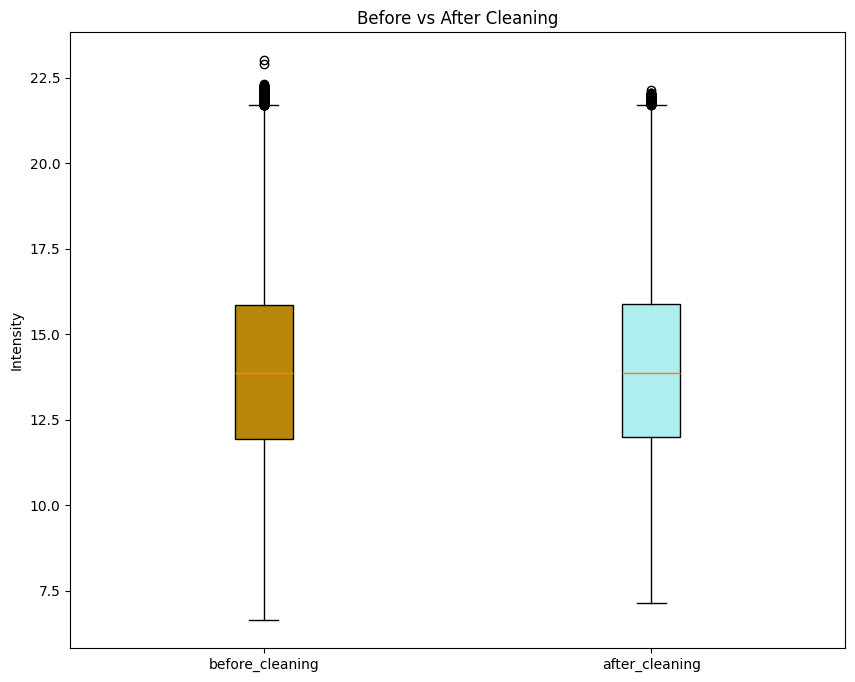

In [44]:
# select groups
before = plot_dat[plot_dat.index == 'before_cleaning']
after = plot_dat[plot_dat.index == 'after_cleaning']

# flatten + remove NaNs
before_vals = before.to_numpy(dtype=float).ravel()
before_vals = before_vals[~np.isnan(before_vals)]

after_vals = after.to_numpy(dtype=float).ravel()
after_vals = after_vals[~np.isnan(after_vals)]

fig, ax = plt.subplots(figsize=(10, 8))

# boxplots
bplot = ax.boxplot(
    [before_vals, after_vals],
    patch_artist=True,
    tick_labels=['before_cleaning', 'after_cleaning']
)

# colors
colors = ['darkgoldenrod', 'paleturquoise']

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Intensity')
ax.set_title('Before vs After Cleaning')

plt.show()

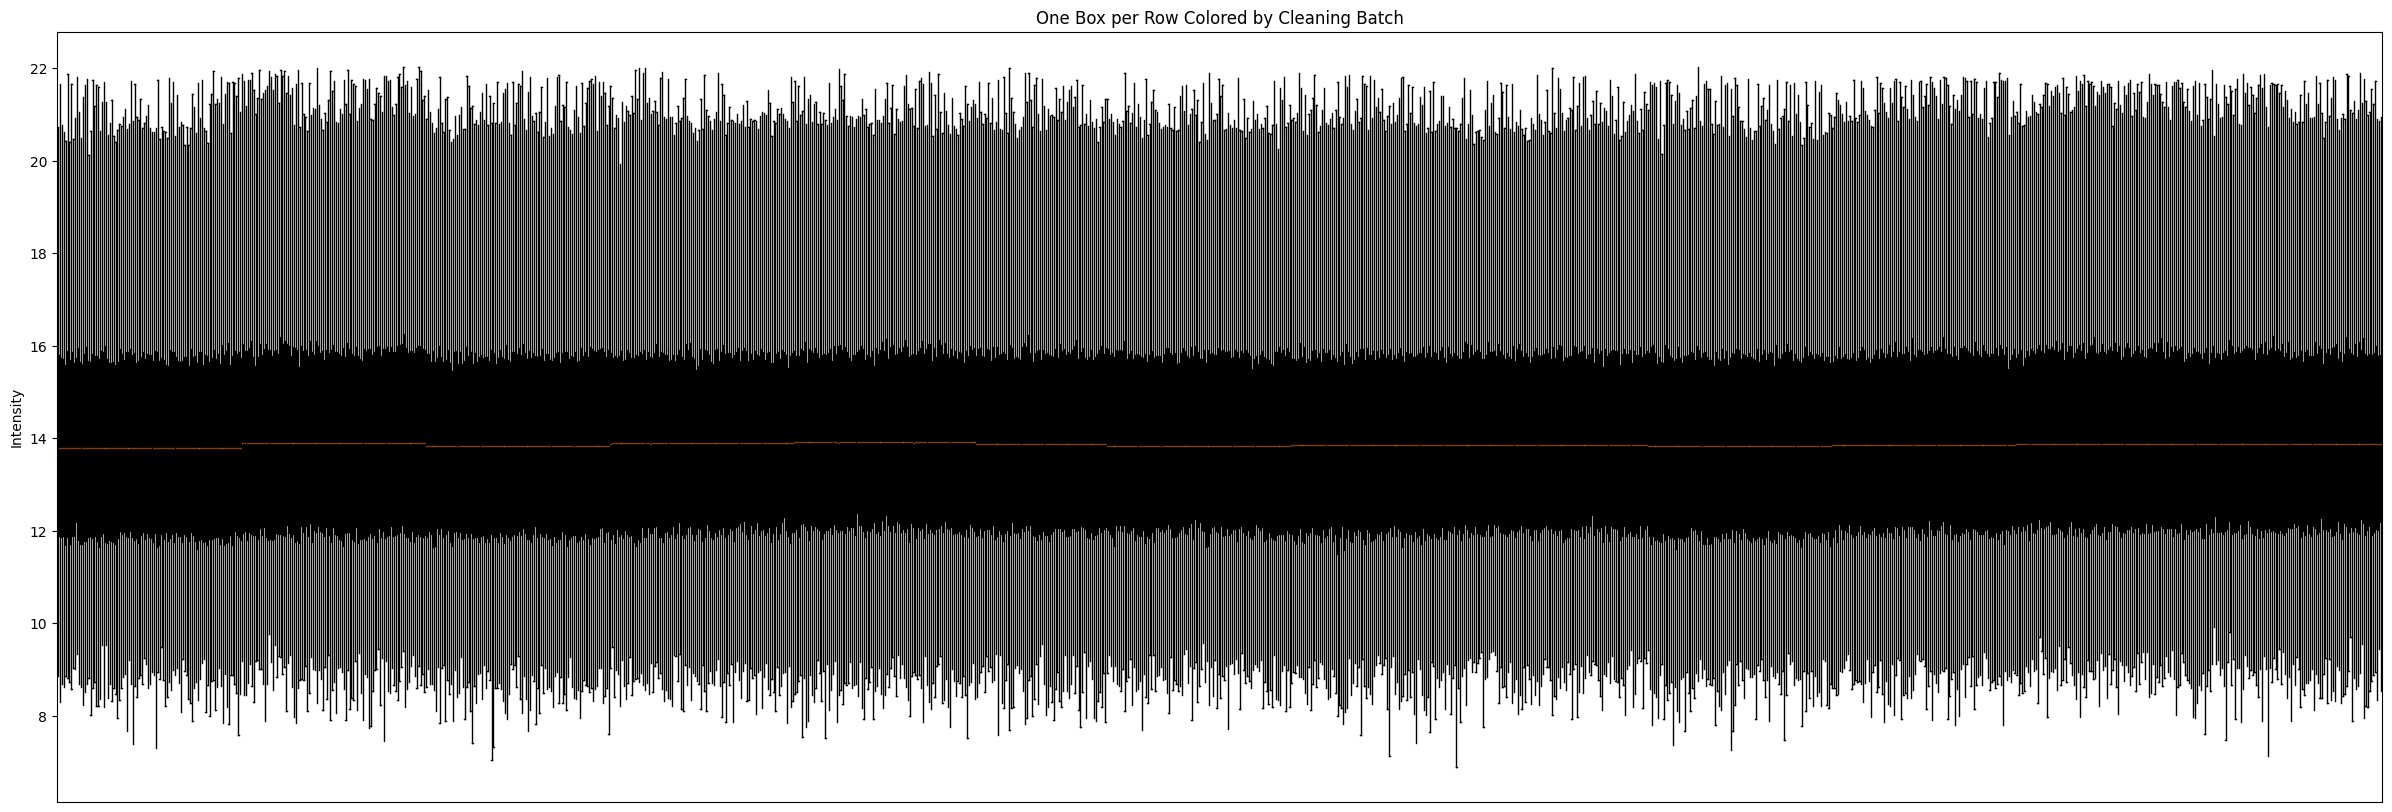

In [45]:

# colors by group
color_dict = {
    'before_cleaning': 'darkgoldenrod',
    'after_cleaning': 'paleturquoise'
}

# one color per row
colors = [color_dict[idx] for idx in plot_dat.index]

# one box per row
data = [
    row[~np.isnan(row)]
    for row in plot_dat.to_numpy(dtype=float)
]

fig, ax = plt.subplots(figsize=(30, 10))
# create boxplots
bplot = ax.boxplot(
    data,
    patch_artist=True,
    showfliers=False
)

# color each box
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# optional aesthetics
ax.set_ylabel('Intensity')
ax.set_title('One Box per Row Colored by Cleaning Batch')

# remove 1212 x tick labels
ax.set_xticks([])

plt.show()

In [46]:
print(np.min(before_vals), np.max(before_vals))
print(np.min(after_vals), np.max(after_vals))

6.637979 23.010342
7.129853 22.140196


# number of proteins
n_proteins = plot_dat.shape[1]

# grid settings
ncols = 4
nrows = int(np.ceil(n_proteins / ncols))

# create figure grid
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4 * nrows)
)

# flatten axes array for easy indexing
axes = axes.flatten()

# colors
colors = ['darkgoldenrod', 'paleturquoise']

for i, col in enumerate(plot_dat.columns):

    # remove NaNs
    before_vals = before[col].dropna().astype(float)
    after_vals = after[col].dropna().astype(float)

    # create boxplot
    bplot = axes[i].boxplot(
        [before_vals, after_vals],
        patch_artist=True,
        tick_labels=['before', 'after'],
        showfliers=False
    )

    # color boxes
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    # titles / labels
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Intensity')

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


In [48]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# PCA to look at Batch Effect

In [57]:
## pca 
def apply_pca(dat, samp_map, file_str = ""):
    df_t = dat.transpose()
    df_t['name_from_intensity'] = df_t.index ## samples as rows
    df_t['pnum'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[2], axis = 1)
    ## add the plate info!
    df_t = pd.merge(df_t, samp_map, on = "pnum", how = "left")
    df_t_int = df_t.filter(regex="[0-9]", axis = 1) #.dropna(how = "all")  ## axis - 1 for cols ; drop to remove peptides IDed but not quantified

    ## FOR PCA ONLY - do something to NAs
    df_no_nas = df_t_int.fillna(0, inplace = False)

    pca = decomposition.PCA(n_components=2)
    pca.fit(df_no_nas)
    pc = pca.transform(df_no_nas)

    pc_df = pd.DataFrame(
        data=pc,
        columns = ['pc1', 'pc2'],
        index=df_t['plate_num']    
    )

    df_name = str(file_str)
    ## get palette
    print("there are a total of ", len(samp_map['plate_num'].unique()), " unique plates.")
    palette_len = len(samp_map['plate_num'].unique())
    custom_palette = sns.color_palette("tab20b", palette_len)
    
    ## add plot elements
    ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = custom_palette)
    plt.axhline(y=0, color = "black", ls = "--", alpha = 0.7) 
    plt.axvline(x=0, color = "black", ls = "--", alpha = 0.7) 
    #pc_df.apply(lambda x: ax.text(x['PC1']+0.05, x['PC2'], x.name), axis=1);
    plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)')
    plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)')
    ax.set(title = f"PCA: {df_name}")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
    plt.axis('equal')
    ax.figure.savefig(f"results/qc_pca_{df_name}.png", dpi = 300,  bbox_inches='tight') 


In [ ]:
pg_log2.drop(["name_from_intensity","plate_num"], axis = 1).head()

there are a total of  14  unique plates.


/tmp/ipykernel_19406/3243752906.py:30: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = custom_palette)


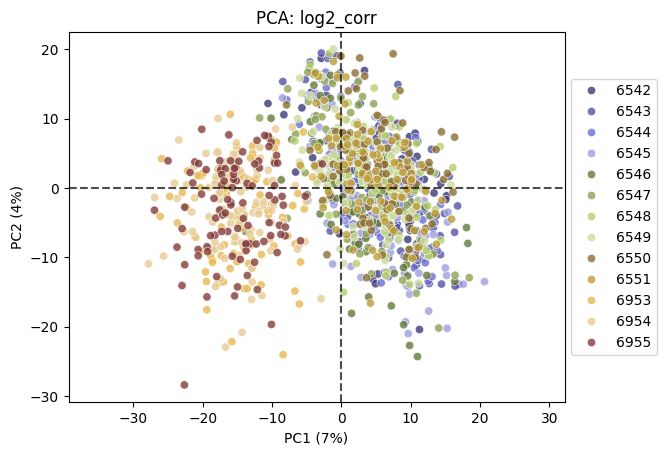

In [56]:
apply_pca(pg_log2.drop(["name_from_intensity","plate_num"], axis = 1).T, samp_map, "log2_corr")


In [75]:
df_t = pg_log2.drop(["name_from_intensity","plate_num"], axis = 1)
df_t['name_from_intensity'] = df_t.index
df_t['pnum'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[2], axis = 1)
    ## add the plate info!
df_t = pd.merge(df_t, samp_map, on = "pnum", how = "left")
df_t_int = df_t.filter(regex="[0-9]", axis = 1) #.dropna(how = "all")  ## axis - 1 for cols ; drop to remove peptides IDed but not quantified

    ## FOR PCA ONLY - do something to NAs
df_no_nas = df_t_int.fillna(np.log2(min_intensity))
df_no_nas.head()
np.log2(min_intensity)

np.float64(5.511702059739086)

there are a total of  14  unique plates.


/tmp/ipykernel_19406/1581249215.py:19: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = custom_palette)


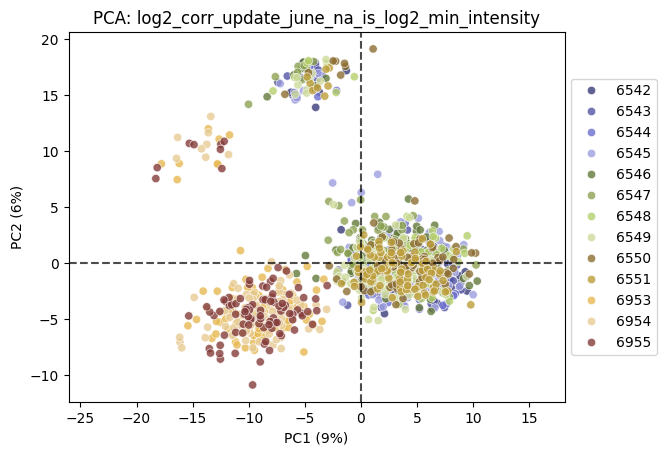

In [74]:
file_str = "log2_corr_update_june_na_is_log2_min_intensity"
pca = decomposition.PCA(n_components=2)
pca.fit(df_no_nas)
pc = pca.transform(df_no_nas)

pc_df = pd.DataFrame(
        data=pc,
        columns = ['pc1', 'pc2'],
        index=df_t['plate_num']    
)

df_name = str(file_str)
   ## get palette
print("there are a total of ", len(samp_map['plate_num'].unique()), " unique plates.")
palette_len = len(samp_map['plate_num'].unique())
custom_palette = sns.color_palette("tab20b", palette_len)
    
    ## add plot elements
ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = custom_palette)
plt.axhline(y=0, color = "black", ls = "--", alpha = 0.7) 
plt.axvline(x=0, color = "black", ls = "--", alpha = 0.7) 
    #pc_df.apply(lambda x: ax.text(x['PC1']+0.05, x['PC2'], x.name), axis=1);
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)')
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)')
ax.set(title = f"PCA: {df_name}")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.axis('equal')
ax.figure.savefig(f"results/qc_pca_{df_name}.png", dpi = 300, bbox_inches='tight') 


In [ ]:
apply_pca2(pg_log2.drop(["name_from_intensity","plate_num"], axis = 1).T, samp_map, "log2_corr_updated")


## Correcting for before and after MS cleaning

We see a batch effect for samples processed before and after the MS cleaning. I'm applying an additional median centering step to try to account for this without having to do anything to the NAs


In [ ]:
pg_log2.head() ## we still see NAs as NaN
pg_log2['batch_info'] = None
plate_str = pg_log2['plate_num'].astype(str)

pg_log2.loc[plate_str.str.startswith('65'), 'batch_info'] = 'before_cleaning'
pg_log2.loc[plate_str.str.startswith('69'), 'batch_info'] = 'after_cleaning'

pg_log2.head()

In [ ]:
log2_df.head()
log2_df['row_median'] = log2_df.drop(['batch_info'], axis = 1).apply(lambda x: x.median(), axis=1)
log2_df.head()

In [35]:
pg_log2.sort_index(inplace = True)
#log2_df['name_from_intensity'] = log2_df.index
#log2_df['plate_num'] = log2_df.apply(lambda x:  x['name_from_intensity'].split("_")[0], axis = 1)
log2_df = pg_log2.drop(['name_from_intensity','plate_num'],axis = 1) #.groupby(['batch_info'])
## now calculate one median value per group (before  /  after ms clean
group_medians = pd.DataFrame(pg_log2.drop(['name_from_intensity', 'plate_num'], axis = 1).groupby(['batch_info']).median()).apply(lambda x: x.median(),axis = 1)

log2_df['row_median'] = log2_df.drop(['batch_info'], axis = 1).apply(lambda x: x.median(), axis=1) ## sample median, calc without low values
log2_df['group_mean'] = log2_df.groupby('batch_info')['row_median'].transform('mean') ## batch mean of medians


medians = log2_df['row_median'] ## samples as rows, aka sample medians
group_means = log2_df['group_mean'] ## mean of plate medians
    
# drop the last two columns for the intensity calculations
df_t_int = log2_df.drop(['batch_info'], axis = 1)
corrected_intensities = (df_t_int.div(medians, axis=0)).mul(group_means, axis=0)
## make columns numeric not objectdataset_2
cols = corrected_intensities.columns
corrected_intensities[cols] = corrected_intensities[cols].apply(pd.to_numeric, errors='coerce')

## drop na coolumns (unlikely but possible)
corrected_intensities = corrected_intensities.dropna(axis = 1, how = "all")
corrected_intensities
#pgroup_medians
#group_means = round(group_medians.mean(),6)
#group_means

,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,A0A075B6Q5,...,Q9NPH3,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7,row_median,group_mean
name_from_intensity,,,,,,,,,,,,,,,,,,,,,
6542_A01_P091451_P01_R1_4367,17.471937,11.095121,13.819326,13.617096,12.134902,14.283826,13.785160,10.870485,12.222180,15.029431,...,10.764580,11.772497,12.312289,13.594164,10.699585,12.659824,11.974268,12.318634,13.857196,13.932852
6542_A02_P091452_P01_R1_4368,17.780074,NaN,12.082018,13.338591,13.257159,12.225821,11.306465,11.136786,11.315547,15.565957,...,NaN,11.420112,12.140199,12.795868,11.363729,12.597558,10.328557,12.406409,13.857196,13.932947
6542_A03_P091453_P01_R1_4369,18.052921,NaN,8.738841,13.342210,13.060047,12.694522,13.540884,10.346900,11.635160,15.676624,...,10.844547,11.242210,12.332393,12.539465,10.503663,12.588402,11.364283,11.984803,13.857196,13.932856
6542_A04_P091454_P01_R1_4370,17.317622,11.894845,13.106001,13.767649,12.867370,14.270570,13.289235,10.626532,11.369331,14.867309,...,11.742901,12.241799,12.472308,13.063553,10.161119,12.679391,10.962121,11.604688,13.857196,13.933039
6542_A05_P091455_P01_R1_4371,17.214995,10.065721,13.508717,12.998225,11.758428,14.175706,13.146278,10.343641,11.515081,14.981190,...,10.712003,11.325545,11.546760,13.818448,10.948753,12.593238,12.256975,12.849111,13.857196,13.932852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6955_H08_P100200_P13_R1_1_1_18943,18.249258,10.816248,14.796991,14.296614,15.358422,13.174146,11.377007,10.358270,10.722551,15.034007,...,10.983105,10.935929,11.997427,12.509259,10.778922,12.681852,11.723424,12.583112,13.864821,13.860701
6955_H09_P100201_P13_R1_1_1_18944,18.665925,NaN,14.997257,NaN,15.316209,13.215335,13.574531,11.279475,10.839572,15.982185,...,11.150973,10.947390,11.871924,12.647868,11.477786,12.101129,11.843317,12.659564,13.864821,13.860531
6955_H10_P100202_P13_R1_1_1_18945,18.416553,8.337020,14.307252,NaN,15.688707,14.010681,12.698574,11.744170,11.261698,15.664729,...,11.145070,10.377130,11.876563,12.234419,10.568054,12.025918,11.421225,12.115648,13.864821,13.860554


In [36]:
import numpy as np

#  per-sample (row) median, excluding batch_info
data_cols = log2_df.columns.difference(['batch_info'])
row_medians = log2_df[data_cols].median(axis=1)  # Series, one value per row

#  per-batch (before / after ms clean) mean of those row medians
batch_group_means = (
    row_medians
    .groupby(log2_df['batch_info'])
    .transform('mean')
)  # Series, same index as row_medians

#  Median-center: divide each row by its median, multiply by its batch mean
corrected = log2_df[data_cols].div(row_medians, axis=0).mul(batch_group_means, axis=0).drop(['group_mean', 'row_median'], axis = 1) ## remove after visually confirming its not weird
corrected.head()

,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,A0A075B6Q5,...,Q9BXR6,Q9HDC9,Q9NPH3,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7
name_from_intensity,,,,,,,,,,,,,,,,,,,,,
6542_A01_P091451_P01_R1_4367,17.471778,11.095020,13.819200,13.616972,12.134791,14.283695,13.785034,10.870386,12.222068,15.029294,...,13.582549,10.869067,10.764482,11.772390,12.312177,13.594040,10.699488,12.659709,11.974158,12.318521
6542_A02_P091452_P01_R1_4368,17.769273,NaN,12.074678,13.330488,13.249105,12.218394,11.299597,11.130020,11.308673,15.556501,...,13.820888,10.786795,NaN,11.413175,12.132824,12.788095,11.356825,12.589905,10.322283,12.398873
6542_A03_P091453_P01_R1_4369,18.050289,NaN,8.737567,13.340265,13.058143,12.692671,13.538910,10.345392,11.633464,15.674338,...,13.937445,NaN,10.842966,11.240571,12.330595,12.537637,10.502131,12.586566,11.362626,11.983056
6542_A04_P091454_P01_R1_4370,17.302926,11.884750,13.094879,13.755965,12.856450,14.258459,13.277957,10.617514,11.359683,14.854692,...,13.741782,11.379779,11.732935,12.231411,12.461724,13.052467,10.152496,12.668631,10.952819,11.594840
6542_A05_P091455_P01_R1_4371,17.214838,10.065629,13.508594,12.998106,11.758320,14.175576,13.146158,10.343547,11.514976,14.981054,...,13.414149,NaN,10.711905,11.325442,11.546655,13.818322,10.948653,12.593123,12.256863,12.848994


In [37]:
import numpy as np

data_cols = log2_df.columns.difference(['batch_info'])

# Per-sample row median
row_medians = log2_df[data_cols].median(axis=1)

# Global median of all row medians (the common reference)
global_median = row_medians.median()

# Subtract each sample's median, then add back the global median
corrected = log2_df[data_cols].sub(row_medians, axis=0) + global_median

Using the two methods above gives basically the same pca below - iomplying that median centering is insufficient to account for the batch effect (median only accounts for additive effects) 

so now i want to take the imputed DF (no "before/after correction") and imput that to pycombat


## NA Imputation

we are going to try a nearest neighbord imputation method and hope for the best. 

In [38]:
import numpy as np
from sklearn.impute import KNNImputer


In [39]:
### old: impute on df that didn't work with median centering for ms cleaning batch
nan = np.nan
imputer = KNNImputer(n_neighbors=5, weights="distance")
imputed_df = imputer.fit_transform(corrected)
imputed_df = pd.DataFrame(imputed_df)
imputed_df.index = corrected.index
imputed_df.columns = corrected.columns
imputed_df.head()

,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,A0A075B6Q5,...,Q9NPH3,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7,group_mean,row_median
name_from_intensity,,,,,,,,,,,,,,,,,,,,,
6542_A01_P091451_P01_R1_4367,17.459280,11.117090,13.826503,13.625371,12.151225,14.288480,13.792522,10.893674,12.238029,15.030037,...,10.788344,11.790788,12.327649,13.602563,10.723702,12.673297,11.991463,12.333959,13.939412,13.864167
6542_A02_P091452_P01_R1_4368,17.757465,11.324912,12.090388,13.340129,13.259140,12.233409,11.319052,11.150296,11.328084,15.555386,...,11.058870,11.432081,12.148253,12.800357,11.376004,12.603125,10.346462,12.413016,13.931255,13.855916
6542_A03_P091453_P01_R1_4369,18.035224,11.167655,8.771723,13.350094,13.069463,12.705923,13.547689,10.371050,11.652314,15.671831,...,10.865994,11.261498,12.345761,12.551708,10.526961,12.600379,11.382908,12.000058,13.937533,13.862283
6542_A04_P091454_P01_R1_4370,17.294177,11.900918,13.105482,13.763528,12.868149,14.263711,13.287718,10.639509,11.378265,14.857202,...,11.749801,12.245984,12.475238,13.063265,10.176630,12.681194,10.973272,11.612341,13.928018,13.852587
6542_A05_P091455_P01_R1_4371,17.203733,10.093280,13.517580,13.009860,11.776795,14.180947,13.157109,10.369691,11.534770,14.982058,...,10.736052,11.346263,11.566277,13.825629,10.971517,12.607072,12.272635,12.861556,13.939412,13.864167


In [40]:
pg_dat = pg_log2.drop(['name_from_intensity','plate_num','batch_info'], axis = 1)

In [41]:
### new: impute on pg_log2 df 
nan = np.nan
imputer = KNNImputer(n_neighbors=5, weights="distance", keep_empty_features = True) ## closer neighbors given more weight
imputed_df = imputer.fit_transform(pg_dat)
imputed_df = pd.DataFrame(imputed_df)
imputed_df.index = pg_dat.index
imputed_df.columns = pg_dat.columns
imputed_df.head()

,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,A0A075B6Q5,...,Q9BXR6,Q9HDC9,Q9NPH3,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7
name_from_intensity,,,,,,,,,,,,,,,,,,,,,
6542_A01_P091451_P01_R1_4367,17.377064,11.034874,13.744287,13.543155,12.069009,14.206264,13.710306,10.811458,12.155813,14.947821,...,13.508918,10.810146,10.706128,11.708572,12.245433,13.520347,10.641486,12.591081,11.909247,12.251743
6542_A02_P091452_P01_R1_4368,17.683407,11.257748,12.016330,13.266071,13.185082,12.159351,11.244994,11.076237,11.254026,15.481328,...,13.754102,10.734670,11.057810,11.358023,12.074195,12.726299,11.301946,12.529067,10.272403,12.338958
6542_A03_P091453_P01_R1_4369,17.954887,11.120000,8.691386,13.269757,12.989126,12.625586,13.467352,10.290713,11.571977,15.591494,...,13.863781,10.862788,10.785657,11.181161,12.265424,12.471371,10.446624,12.520042,11.302571,11.919721
6542_A04_P091454_P01_R1_4370,17.223355,11.830096,13.034660,13.692706,12.797327,14.192889,13.216896,10.568687,11.307443,14.786380,...,13.678588,11.327447,11.678979,12.175162,12.404416,12.992443,10.105808,12.610372,10.902450,11.541519
6542_A05_P091455_P01_R1_4371,17.121517,10.011064,13.435364,12.927644,11.694579,14.098731,13.074893,10.287475,11.452554,14.899842,...,13.341431,10.364821,10.653836,11.264047,11.484061,13.743413,10.889301,12.524856,12.190419,12.779340


there are a total of  14  unique plates.


/tmp/ipykernel_19296/4243387329.py:30: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = custom_palette)


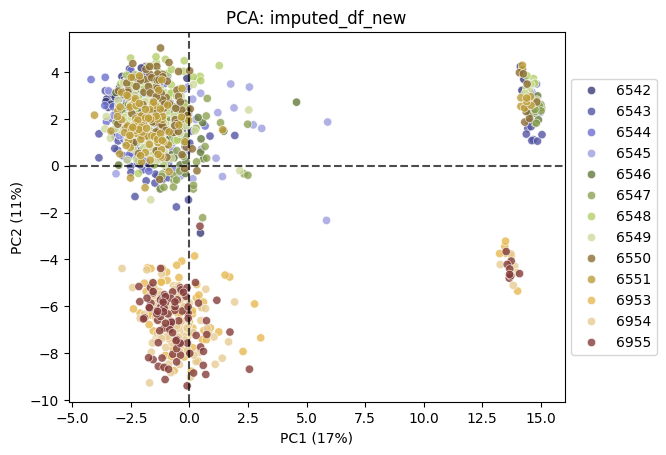

In [42]:
apply_pca(imputed_df.T, samp_map, "imputed_df_new")


/tmp/ipykernel_19296/4261486789.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab20', len(batches))


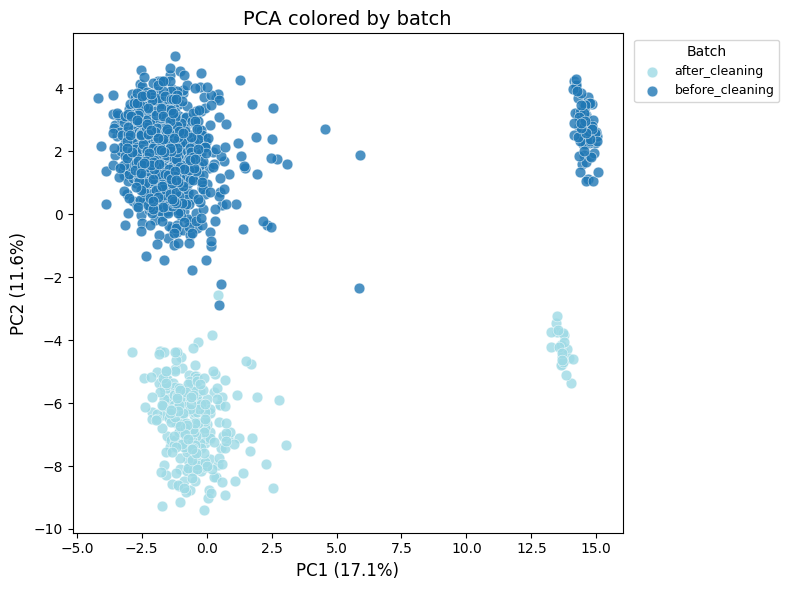

In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Scale the corrected data
scaler = StandardScaler()
scaled = scaler.fit_transform(imputed_df)

# Step 2: PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(imputed_df)
var_explained = pca.explained_variance_ratio_ * 100

# Step 3: Build plot df
pca_df = pd.DataFrame({'PC1': pcs[:, 0], 'PC2': pcs[:, 1], 'batch_info': pg_log2['batch_info']})

# Step 4: Assign a color per batch
batches = pca_df['batch_info'].unique()
palette = cm.get_cmap('tab20', len(batches))
color_map = {batch: palette(i) for i, batch in enumerate(batches)}

# Step 5: Plot
fig, ax = plt.subplots(figsize=(8, 6))

for batch, group in pca_df.groupby('batch_info'):
    ax.scatter(group['PC1'], group['PC2'],
               label=batch,
               color=color_map[batch],
               s=60, alpha=0.8, edgecolors='white', linewidths=0.4)

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=12)
ax.set_title('PCA colored by batch', fontsize=14)
ax.legend(title='Batch', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

ax.figure.savefig(f"results/qc_pca_imputed_nas_log2_new.png") 

/tmp/ipykernel_19296/1478801111.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab20', len(batches))


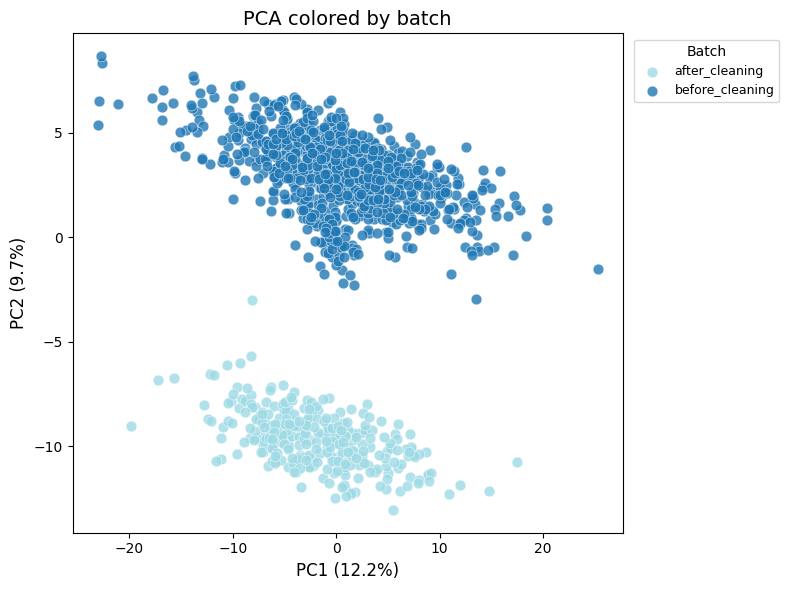

In [44]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Scale the corrected data
scaler = StandardScaler()
scaled = scaler.fit_transform(imputed_df)

# Step 2: PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(scaled)
var_explained = pca.explained_variance_ratio_ * 100

# Step 3: Build plot df
pca_df = pd.DataFrame({'PC1': pcs[:, 0], 'PC2': pcs[:, 1], 'batch_info': pg_log2['batch_info']})

# Step 4: Assign a color per batch
batches = pca_df['batch_info'].unique()
palette = cm.get_cmap('tab20', len(batches))
color_map = {batch: palette(i) for i, batch in enumerate(batches)}

# Step 5: Plot
fig, ax = plt.subplots(figsize=(8, 6))

for batch, group in pca_df.groupby('batch_info'):
    ax.scatter(group['PC1'], group['PC2'],
               label=batch,
               color=color_map[batch],
               s=60, alpha=0.8, edgecolors='white', linewidths=0.4)

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=12)
ax.set_title('PCA colored by batch', fontsize=14)
ax.legend(title='Batch', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

ax.figure.savefig(f"results/qc_pca_imputed_nas_log2_scaled_new.png") 

feedback from Matthew: apply combat on before / after MS run, but not general plate number. 

We definitely see a batch effect, but it is modest after correct (only explains 8% of the data). 

## PyCombat 


In [46]:
from inmoose.pycombat import pycombat_norm


In [47]:
## set up df 
info_cols = log2_df['batch_info']
imputed_df = pd.merge(imputed_df, info_cols, left_index = True, right_index = True)
imputed_group = imputed_df['batch_info']
imputed_intensities = imputed_df.drop(['batch_info'], axis = 1)

In [48]:
## confirming no NaNs
imputed_df[imputed_df.isna().any(axis=1)]


,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,A0A075B6Q5,...,Q9HDC9,Q9NPH3,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7,batch_info
name_from_intensity,,,,,,,,,,,,,,,,,,,,,


In [49]:
imputed_intensities.dtypes

A0A075B6H7    float64
A0A075B6H9    float64
A0A075B6I0    float64
A0A075B6I1    float64
A0A075B6I9    float64
               ...   
Q9UGM5        float64
Q9UHG3        float64
Q9UK55        float64
Q9Y5Y7        float64
Q9Y6R7        float64
Length: 327, dtype: object

In [50]:

# expects features x samples (transpose if needed)
corrected_combat = pycombat_norm(imputed_intensities.T, imputed_group)
corrected_combat = corrected_combat.T  # back to samples x features

In [57]:
combat_df =  pd.merge(corrected_combat, info_cols, left_index = True, right_index = True)
combat_df.head()
combat_intensities = combat_df.drop(['batch_info'], axis = 1)

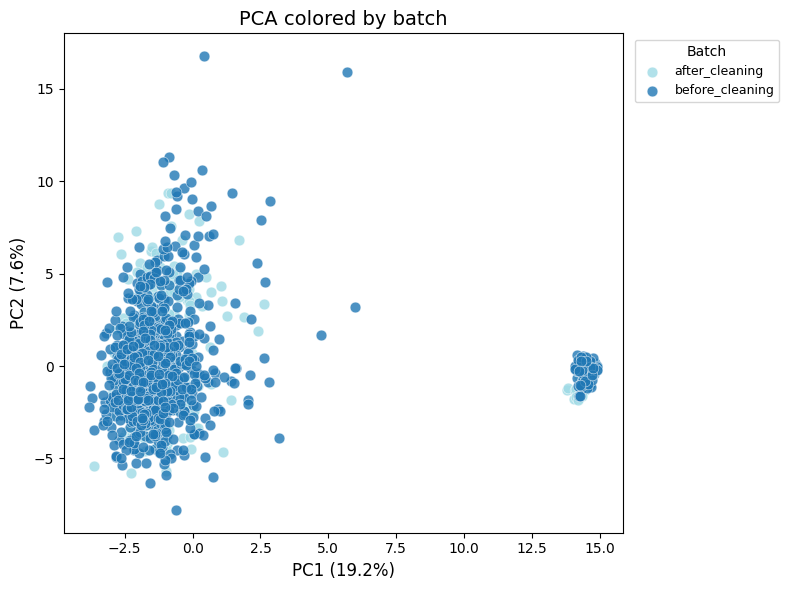

In [59]:
## pca on pycombat data

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Scale the corrected data
scaler = StandardScaler()
scaled = scaler.fit_transform(combat_intensities)

# Step 2: PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(combat_intensities)
var_explained = pca.explained_variance_ratio_ * 100

# Step 3: Build plot df
pca_df = pd.DataFrame({'PC1': pcs[:, 0], 'PC2': pcs[:, 1], 'batch_info': combat_df['batch_info']})

# Step 4: Assign a color per batch
batches = pca_df['batch_info'].unique()
palette = cm.get_cmap('tab20', len(batches))
color_map = {batch: palette(i) for i, batch in enumerate(batches)}

# Step 5: Plot
fig, ax = plt.subplots(figsize=(8, 6))

for batch, group in pca_df.groupby('batch_info'):
    ax.scatter(group['PC1'], group['PC2'],
               label=batch,
               color=color_map[batch],
               s=60, alpha=0.8, edgecolors='white', linewidths=0.4)

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=12)
ax.set_title('PCA colored by batch', fontsize=14)
ax.legend(title='Batch', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

ax.figure.savefig(f"results/qc_pca_combat_and_imputed_not_scaled.png") 